In [ ]:
import pandas as pd
from pathlib import Path

csv_path = Path("..") / "results" / "part1" / "results_part1.csv"
df = pd.read_csv(csv_path)
df.head()

C:\Users\ennio\Documents\MastersLocal\CCA\cloud-comp-arch-project-fork\results\part1\results_part1.csv
True
      interference    p95      QPS  target  run
0  no_interference  380.6   4959.8    5000    1
1  no_interference  422.2   9933.8   10000    1
2  no_interference  492.6  14987.0   15000    1
3  no_interference  517.7  20007.4   20000    1
4  no_interference  570.7  25069.0   25000    1


In [20]:
# Resolve column names case-insensitively and verify
cols_lower = {c.lower().strip(): c for c in df.columns}
interference_col = cols_lower.get("interference")
target_col = cols_lower.get("target")
p95_col = cols_lower.get("p95")
qps_col = cols_lower.get("qps")
missing = [
    name for name, col in {
        "interference": interference_col,
        "target": target_col,
        "p95": p95_col,
        "qps": qps_col,
    }.items() if col is None
]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

# Compute mean and std for p95 and qps grouped by interference and target
df_grouped_stats = (
    df.groupby([interference_col, target_col], as_index=False)
      .agg(
          avg_p95=(p95_col, "mean"),
          std_p95=(p95_col, "std"),
          avg_qps=(qps_col, "mean"),
          std_qps=(qps_col, "std"),
      )
      .sort_values([interference_col, target_col])
)

# Convert p95 stats from microseconds to milliseconds
df_grouped_stats[["avg_p95", "std_p95"]] = df_grouped_stats[["avg_p95", "std_p95"]] / 1000

df_grouped_stats.head()

,interference,target,avg_p95,std_p95,avg_qps,std_qps
0,cpu,5000,1.407533,0.153020,4983.133333,33.200201
1,cpu,10000,1.547133,0.047682,10026.733333,27.800959
2,cpu,15000,1.645433,0.026577,14989.733333,31.820957
3,cpu,20000,1.687833,0.028251,20045.400000,32.673537
4,cpu,25000,4.810933,1.241134,24029.666667,625.437330


Averaged across 3 runs per target/configuration point.


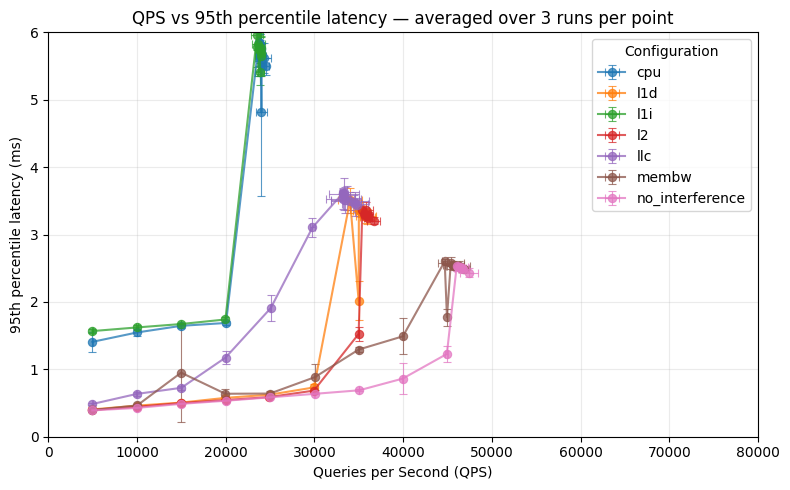

In [69]:
import matplotlib.pyplot as plt

n_runs = int(df['run'].nunique())

fig, ax = plt.subplots(figsize=(8, 5))
for cfg in sorted(df_grouped_stats['interference'].unique()):
    sub = df_grouped_stats[df_grouped_stats['interference'] == cfg].sort_values('avg_qps')
    ax.errorbar(
        sub['avg_qps'],
        sub['avg_p95'],
        xerr=sub['std_qps'],
        yerr=sub['std_p95'],
        label=cfg,
        marker='o',
        capsize=3,
        alpha=0.75,
        markersize=6,
        markeredgewidth=0.8,
        elinewidth=0.8
    )

ax.set_xlim(0, 80000)
ax.set_ylim(0, 6)
ax.set_xlabel('Queries per Second (QPS)')
ax.set_ylabel('95th percentile latency (ms)')
ax.set_title(f'QPS vs 95th percentile latency — averaged over {n_runs} runs per point')
ax.legend(title='Configuration', loc='upper right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
print(f'Averaged across {n_runs} runs per target/configuration point.')